# Pseudomonas PINN

## 1. Configure Training


In [1]:
from src.utils import load_pseudomonas_splits
from src.utils.training import TrainingConfig, train_pinn
from src.models.pinn import PseudomonasBIOSODE

PROCESSED_CSV = "data/processed/ambr_preprocessed.csv"
RESULTS_DIR = "results"

SELECTED_EXPERIMENT_ID = "AMBR2_15"
NUM_EPOCHS = 50000

config = TrainingConfig(
    processed_csv=PROCESSED_CSV,
    results_dir=RESULTS_DIR,
    experiment_id=SELECTED_EXPERIMENT_ID,
    experiment_name=f"pseudomonas_pinn_{SELECTED_EXPERIMENT_ID}",
    seed=42,
    n_neurons=20,
    n_hidden_layers=7,
    num_epochs=NUM_EPOCHS,
    learning_rate=1e-4,
    data_loss_weight=1.0,
    residual_loss_weight=1.0,
    auxiliary_loss_weight=1.0,
    regularization_loss_weight=1.0,
    use_softadapt=True,
    obs_fit_weights=(1.0, 1.0, 1.0, 1.0),  # glucose, biomass, O2, pH
    aux_fit_weights=(1.0,) * len(PseudomonasBIOSODE.state_names),
    res_eq_weights=(1e-15,) * len(PseudomonasBIOSODE.state_names),
    reg_eq_weights=(1e-6,) * len(PseudomonasBIOSODE.state_names),
    test_fraction=0.2,
    split_strategy="random",
)

print("Selected experiment:", SELECTED_EXPERIMENT_ID)


Selected experiment: AMBR2_15


## 2. Run Training


In [2]:
train_dataset, test_dataset = load_pseudomonas_splits(
    PROCESSED_CSV,
    experiment_id=SELECTED_EXPERIMENT_ID,
    test_fraction=config.test_fraction,
    split_strategy=config.split_strategy,
    random_seed=config.seed,
)

result = train_pinn(config)
print("\nOutput dir:", result["output_dir"])
print("Final loss:", result["history"]["loss"][-1])
print("Learned params:", result["learned_params"])



Output dir: results/AMBR2_15
Final loss: 0.08487200736999512
Learned params: {'mu_max': 0.00010904630471486598, 'Ksubs': 0.45202332735061646, 'KLaO2': 1.9990516901016235, 'KLaCO2': 476.73883056640625}


## 3. Evaluate and Visualize


### 3.1 Loss, R2 Score

Track total, data, residual, auxiliary, regularization losses, and mean R2 score per epoch.


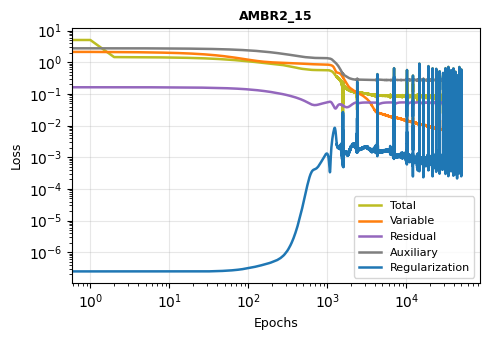

In [3]:
from src.utils.evaluation import plot_loss, plot_r2, plot_r2_by_target

plot_loss(result)


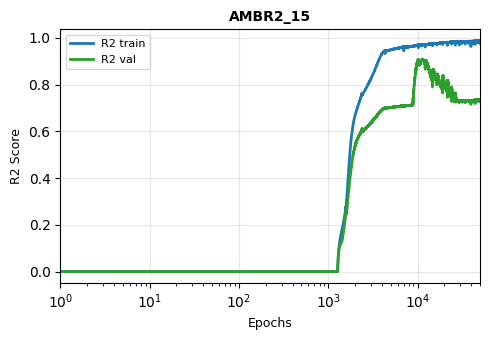

In [4]:
plot_r2(result)


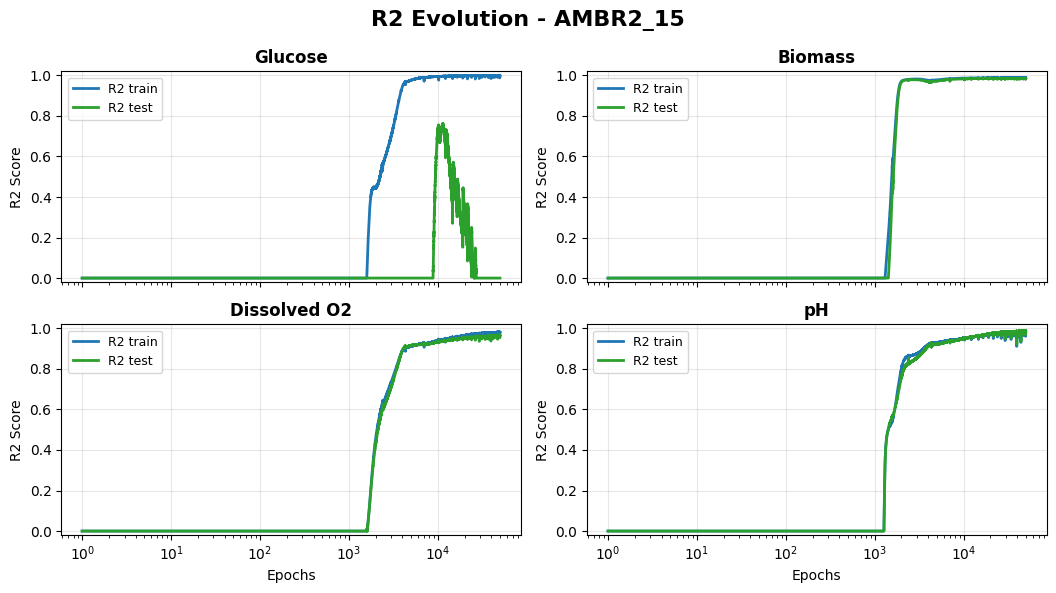

In [5]:
plot_r2_by_target(result)


### 3.2 PINN vs Data

Compare model predictions against measured observables for the selected experiment.


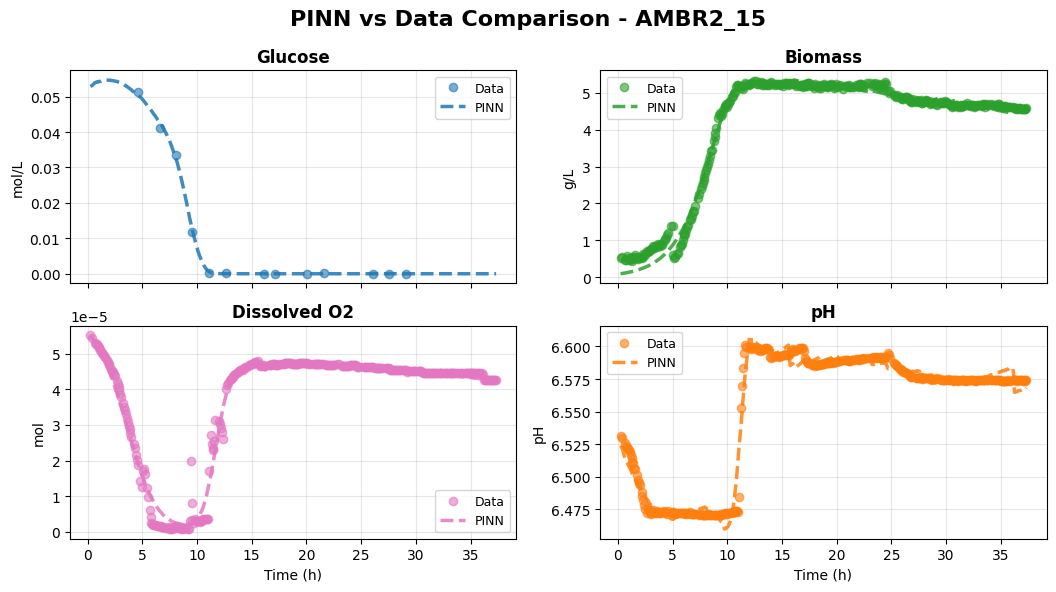

In [6]:
from src.utils.evaluation import plot_observable_predictions

plot_observable_predictions(
    result["model"],
    result["train_dataset"],
    experiment_id=SELECTED_EXPERIMENT_ID,
)


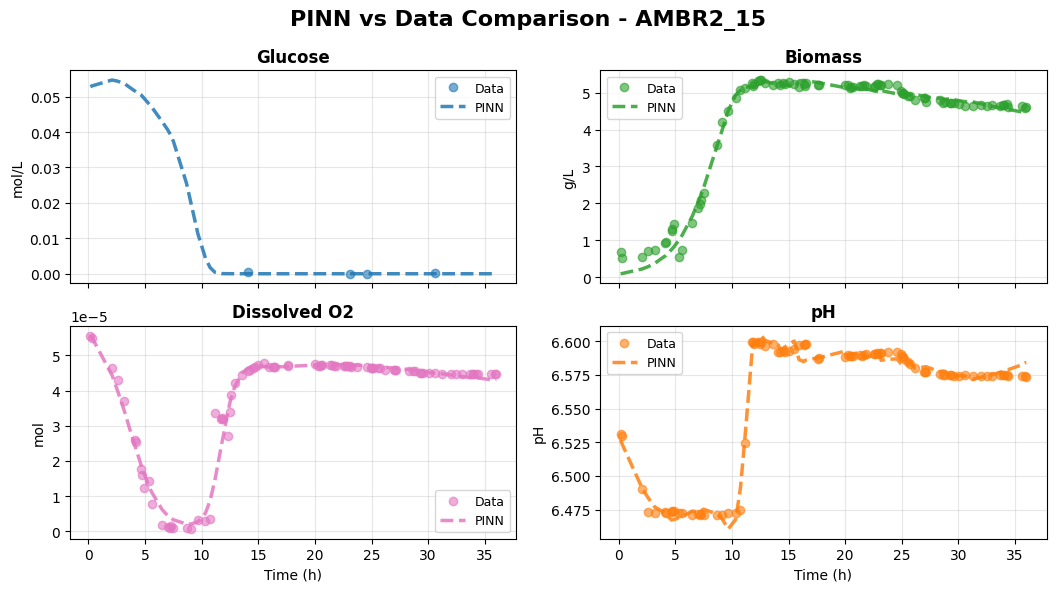

In [7]:
plot_observable_predictions(
    result["model"],
    result["test_dataset"],
    experiment_id=SELECTED_EXPERIMENT_ID,
)


### 3.3 Metrics

Compute train/test observable metrics and save reports.


In [8]:
from src.utils import evaluate_observables, parameter_report, save_reports

train_metrics = evaluate_observables(result["model"], result["train_dataset"])
test_metrics = evaluate_observables(result["model"], result["test_dataset"])
params = parameter_report(result)

print("Train metrics")
display(train_metrics)

print("Test metrics")
display(test_metrics)

print("Parameter report")
display(params)

report_paths = save_reports(result)
report_paths


Train metrics


,observable,n,rmse,mae,r2
0,glucose_mol_l,13,0.000650,0.000377,0.998662
1,biomass_g_l,354,0.182331,0.133395,0.987618
2,O2_l_mol,354,0.000002,0.000001,0.981210
3,pH,354,0.007009,0.004684,0.979691


Test metrics


,observable,n,rmse,mae,r2
0,glucose_mol_l,4,0.000237,0.000152,0.000000
1,biomass_g_l,90,0.192171,0.135674,0.984295
2,O2_l_mol,90,0.000003,0.000001,0.966415
3,pH,90,0.005177,0.003830,0.988203


Parameter report


,parameter,default_value,learned_value,range_low,range_high,relative_change
0,mu_max,0.009,0.000109,9.000000e-06,9.0,-0.987884
1,Ksubs,0.005,0.452023,5.000000e-07,5.0,89.404665
2,KLaO2,2.000,1.999052,2.000000e-03,2000.0,-0.000474
3,KLaCO2,10.000,476.738831,1.000000e-02,10000.0,46.673883


{'metrics_train': PosixPath('results/AMBR2_15/metrics_train.csv'),
 'metrics_test': PosixPath('results/AMBR2_15/metrics_test.csv'),
 'parameters': PosixPath('results/AMBR2_15/parameter_report.csv')}